In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [2]:
final_model = joblib.load("../data/final_xgb_model.pkl")
best_threshold = joblib.load("../data/best_threshold.pkl")

X_test = joblib.load("../data/X_test_engineered.pkl")
y_test = joblib.load("../data/y_test.pkl")

print("Test data:", X_test.shape)
print("Threshold:", best_threshold)

Test data: (61503, 152)
Threshold: 0.6500000000000001


In [3]:
y_test_prob = final_model.predict_proba(X_test)[:, 1]

y_test_pred = (
    y_test_prob >= best_threshold
).astype(int)

print("Test predictions generated!")

Test predictions generated!


In [4]:
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_prob)

print("FINAL TEST RESULTS")
print("------------------")
print("Accuracy :", test_accuracy)
print("Precision:", test_precision)
print("Recall   :", test_recall)
print("F1 Score :", test_f1)
print("ROC-AUC  :", test_auc)

FINAL TEST RESULTS
------------------
Accuracy : 0.8529665219582785
Precision: 0.25841232227488153
Recall   : 0.43927492447129907
F1 Score : 0.32540096978739275
ROC-AUC  : 0.7737303221670874


In [5]:
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["No Default", "Default"]
    )
)

              precision    recall  f1-score   support

  No Default       0.95      0.89      0.92     56538
     Default       0.26      0.44      0.33      4965

    accuracy                           0.85     61503
   macro avg       0.60      0.66      0.62     61503
weighted avg       0.89      0.85      0.87     61503



In [6]:
cm = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[50279  6259]
 [ 2784  2181]]


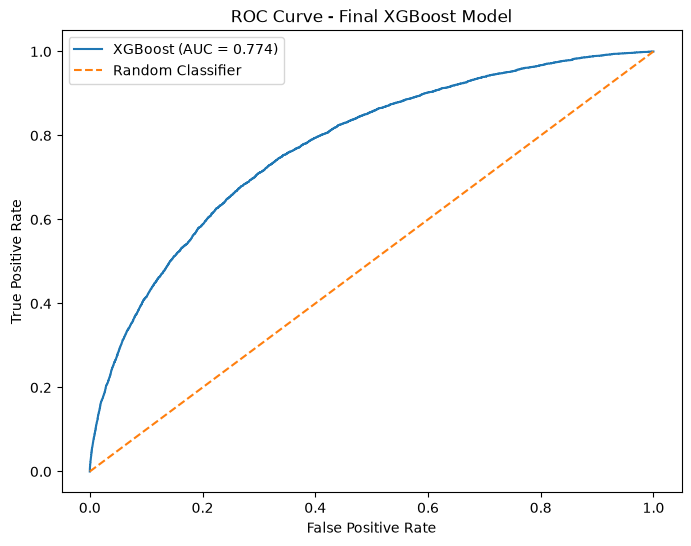

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds_roc = roc_curve(
    y_test,
    y_test_prob
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final XGBoost Model")
plt.legend()

plt.show()

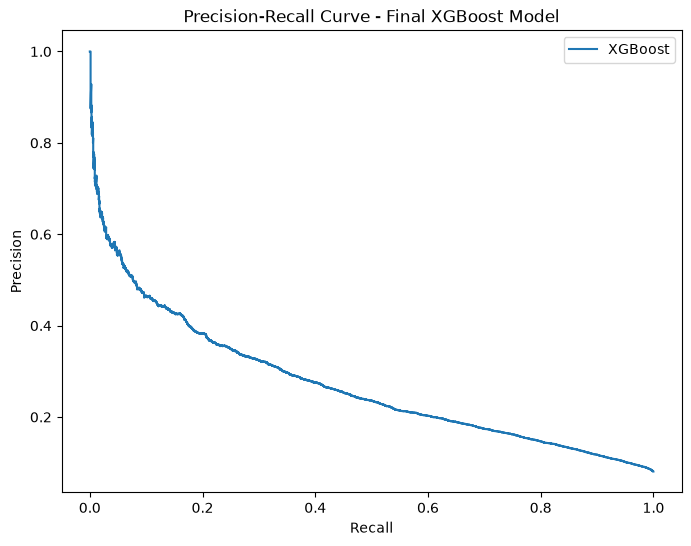

In [8]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds_pr = precision_recall_curve(
    y_test,
    y_test_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    label="XGBoost"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Final XGBoost Model")
plt.legend()

plt.show()

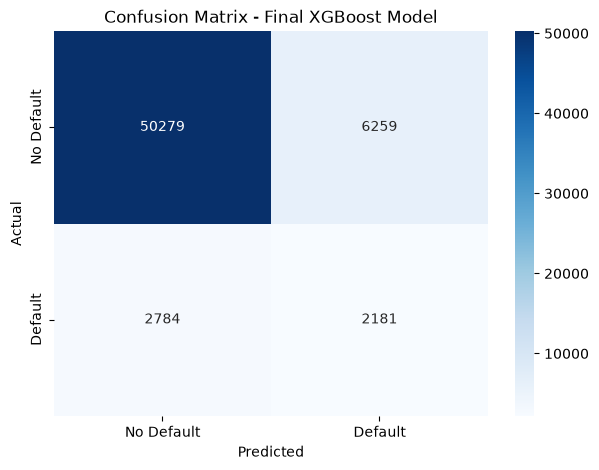

In [9]:
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"]
)

plt.title("Confusion Matrix - Final XGBoost Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [10]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(
    y_test,
    y_test_prob
)

print("Test PR-AUC:", pr_auc)

Test PR-AUC: 0.2710910596219513


In [11]:
final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Score": [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        test_auc,
        pr_auc
    ]
})

final_results

,Metric,Score
0,Accuracy,0.852967
1,Precision,0.258412
2,Recall,0.439275
3,F1 Score,0.325401
4,ROC-AUC,0.773730
5,PR-AUC,0.271091


# Final Model Evaluation

The final Tuned XGBoost model was evaluated on the independent test dataset using the threshold selected from the validation dataset.

The model achieved a test ROC-AUC of approximately 0.774, indicating that it has meaningful discriminatory ability between applicants with and without payment difficulty.

At the selected classification threshold of 0.65, the model achieved an accuracy of approximately 0.853, precision of 0.258, recall of 0.439, and F1-score of 0.325.

Because the dataset is highly imbalanced, accuracy is not considered the primary measure of model performance. Precision, recall, F1-score, ROC-AUC, and PR-AUC provide a more informative assessment of the model's ability to identify applicants experiencing payment difficulty.

The confusion matrix shows that the model correctly identifies 2,181 of the 4,965 applicants with payment difficulty in the test set.